In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import google.generativeai as genai
import os
from google.colab import files
uploaded = files.upload()


Saving food_delivery_dataset.csv to food_delivery_dataset.csv


In [ ]:
df = pd.read_csv(list(uploaded.keys())[0])

df.head()

,ID,Delivery_person_ID,Delivery_person_Age,Delivery_person_Ratings,Restaurant_latitude,Restaurant_longitude,Delivery_location_latitude,Delivery_location_longitude,Order_Date,Time_Orderd,...,Road_traffic_density,Vehicle_condition,Type_of_order,Type_of_vehicle,multiple_deliveries,Festival,City,Time_taken (min),distance_km,delivery_speed
0,0xcdcd,DEHRES17DEL01,36.0,4.2,30.327968,78.046106,30.397968,78.116106,12-02-2022,21:55,...,Jam,2,Snack,motorcycle,3.0,No,Metropolitian,46,10.280582,Slow
1,0xd987,KOCRES16DEL01,21.0,4.7,10.003064,76.307589,10.043064,76.347589,13-02-2022,14:55,...,High,1,Meal,motorcycle,1.0,No,Metropolitian,23,6.242319,Average
2,0x2784,PUNERES13DEL03,23.0,4.7,18.562450,73.916619,18.652450,74.006619,04-03-2022,17:30,...,Medium,1,Drinks,scooter,1.0,No,Metropolitian,21,13.787860,Average
3,0xc8b6,LUDHRES15DEL02,34.0,4.3,30.899584,75.809346,30.919584,75.829346,13-02-2022,09:20,...,Low,0,Buffet,motorcycle,0.0,No,Metropolitian,20,2.930258,Average
4,0xdb64,KNPRES14DEL02,24.0,4.7,26.463504,80.372929,26.593504,80.502929,14-02-2022,19:50,...,Jam,1,Snack,scooter,1.0,No,Metropolitian,41,19.396618,Slow


In [ ]:
df.shape

(38964, 22)

Rows aur Columns

In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 38964
Columns: 22


Column names

In [ ]:
print(df.columns)

Index(['ID', 'Delivery_person_ID', 'Delivery_person_Age',
       'Delivery_person_Ratings', 'Restaurant_latitude',
       'Restaurant_longitude', 'Delivery_location_latitude',
       'Delivery_location_longitude', 'Order_Date', 'Time_Orderd',
       'Time_Order_picked', 'Weather_conditions', 'Road_traffic_density',
       'Vehicle_condition', 'Type_of_order', 'Type_of_vehicle',
       'multiple_deliveries', 'Festival', 'City', 'Time_taken (min)',
       'distance_km', 'delivery_speed'],
      dtype='object')


Data types

In [ ]:
df.dtypes

,0
ID,object
Delivery_person_ID,object
Delivery_person_Age,float64
Delivery_person_Ratings,float64
Restaurant_latitude,float64
Restaurant_longitude,float64
Delivery_location_latitude,float64
Delivery_location_longitude,float64
Order_Date,object
Time_Orderd,object


***Missing Values***

In [ ]:
df.isnull().sum()

,0
ID,0
Delivery_person_ID,0
Delivery_person_Age,1019
Delivery_person_Ratings,1055
Restaurant_latitude,0
Restaurant_longitude,0
Delivery_location_latitude,0
Delivery_location_longitude,0
Order_Date,0
Time_Orderd,835


Duplicate records

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


*TASK B :DATA CLEANING*

In [ ]:
df["Delivery_person_Age"] = df["Delivery_person_Age"].fillna(
    df["Delivery_person_Age"].median()
)

df["Delivery_person_Ratings"] = df["Delivery_person_Ratings"].fillna(
    df["Delivery_person_Ratings"].median()
)

In [ ]:
df = df.dropna(subset=["Time_Orderd"])

In [ ]:
print(df.isnull().sum())

ID                             0
Delivery_person_ID             0
Delivery_person_Age            0
Delivery_person_Ratings        0
Restaurant_latitude            0
Restaurant_longitude           0
Delivery_location_latitude     0
Delivery_location_longitude    0
Order_Date                     0
Time_Orderd                    0
Time_Order_picked              0
Weather_conditions             0
Road_traffic_density           0
Vehicle_condition              0
Type_of_order                  0
Type_of_vehicle                0
multiple_deliveries            0
Festival                       0
City                           0
Time_taken (min)               0
distance_km                    0
delivery_speed                 0
dtype: int64


# *TASK C*

In [ ]:
print("Total Deliveries:", len(df))

Total Deliveries: 38129


In [ ]:
print("Average Delivery Time:", df["Time_taken (min)"].mean())
print("Minimum Delivery Time:", df["Time_taken (min)"].min())
print("Maximum Delivery Time:", df["Time_taken (min)"].max())

Average Delivery Time: 26.582076634582602
Minimum Delivery Time: 10
Maximum Delivery Time: 54


In [ ]:
print("Average Delivery Distance:", df["distance_km"].mean())

Average Delivery Distance: 9.762117184647828


In [ ]:
print("Most Frequent Delivery Speed:", df["delivery_speed"].mode()[0])

Most Frequent Delivery Speed: Average


In [ ]:
print("Average Delivery Person Age:", df["Delivery_person_Age"].mean())
print("Average Delivery Person Rating:", df["Delivery_person_Ratings"].mean())

Average Delivery Person Age: 29.608985286789583
Average Delivery Person Rating: 4.6322720239188016


# *TASK D*

In [ ]:
traffic_time = df.groupby("Road_traffic_density")["Time_taken (min)"].mean()

print(traffic_time)

Road_traffic_density
High      27.385268
Jam       31.417756
Low       21.503816
Medium    26.940107
Name: Time_taken (min), dtype: float64


In [ ]:
print("Highest Average Delivery Time:",
      traffic_time.idxmax())

print("Average Time:",
      traffic_time.max())

Highest Average Delivery Time: Jam
Average Time: 31.417755856966707


In [ ]:
correlation = df["distance_km"].corr(df["Time_taken (min)"])

print("Correlation between Distance and Delivery Time:", correlation)

Correlation between Distance and Delivery Time: 0.32200076499187885


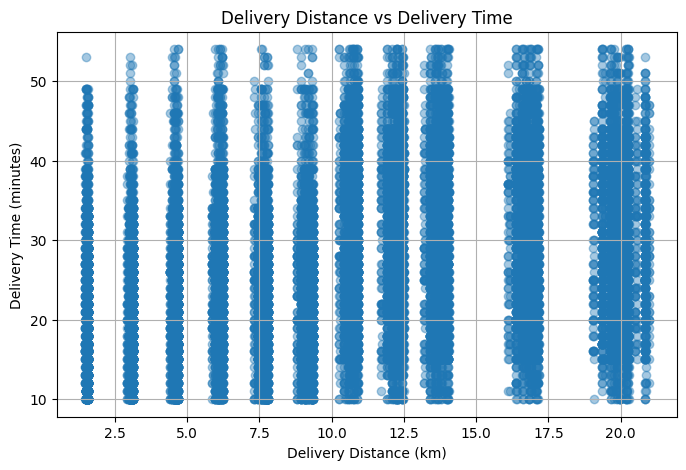

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["distance_km"],
    df["Time_taken (min)"],
    alpha=0.4
)

plt.title("Delivery Distance vs Delivery Time")
plt.xlabel("Delivery Distance (km)")
plt.ylabel("Delivery Time (minutes)")

plt.grid(True)
plt.show()

In [ ]:
weather_traffic = df.groupby(
    ["Weather_conditions", "Road_traffic_density"]
)["Time_taken (min)"].mean()

print(weather_traffic)

Weather_conditions  Road_traffic_density
Cloudy              High                    29.017296
                    Jam                     36.688299
                    Low                     22.438156
                    Medium                  28.848972
Fog                 High                    28.502283
                    Jam                     36.879586
                    Low                     22.489824
                    Medium                  28.476641
Sandstorms          High                    27.971332
                    Jam                     30.221463
                    Low                     20.539357
                    Medium                  27.838835
Stormy              High                    27.882261
                    Jam                     30.177655
                    Low                     20.839189
                    Medium                  27.766185
Sunny               High                    23.592295
                    Jam                  

In [ ]:
print("Highest Average Delivery Time Combination:")
print(weather_traffic.idxmax())

print("Average Delivery Time:")
print(weather_traffic.max())

Highest Average Delivery Time Combination:
('Fog', 'Jam')
Average Delivery Time:
36.87958607714017


TASK E

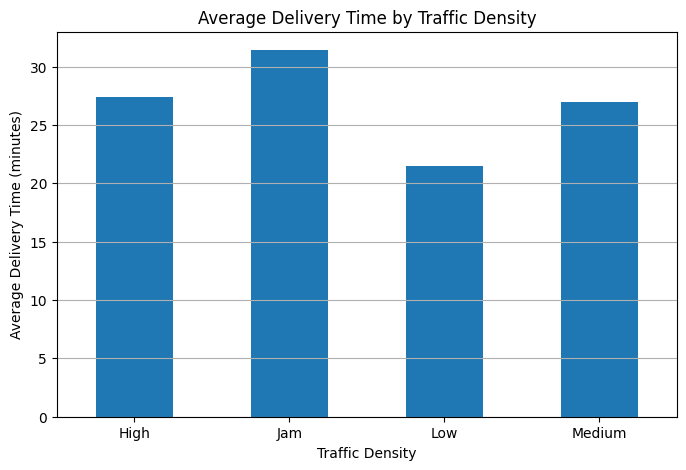

In [ ]:
traffic_avg = df.groupby("Road_traffic_density")["Time_taken (min)"].mean()

traffic_avg.plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Delivery Time by Traffic Density")
plt.xlabel("Traffic Density")
plt.ylabel("Average Delivery Time (minutes)")
plt.xticks(rotation=0)
plt.grid(axis="y")
plt.show()

# *TASK F*

In [ ]:
print("Highest Traffic Condition:")
print(traffic_avg.idxmax(), "=", traffic_avg.max())

print("\nDistance-Time Correlation:")
print(correlation)

print("\nHighest Weather + Traffic Combination:")
print(weather_traffic.idxmax(), "=", weather_traffic.max())

Highest Traffic Condition:
Jam = 31.417755856966707

Distance-Time Correlation:
0.32200076499187885

Highest Weather + Traffic Combination:
('Fog', 'Jam') = 36.87958607714017


## TASK F: BUSINESS INSIGHTS

### 1. Traffic affects delivery time

Deliveries during **Jam traffic** take the longest on average, with an average delivery time of approximately **31.42 minutes**. This suggests that heavy traffic is an important factor causing delivery delays.

**Business Insight:** The company can improve delivery performance by assigning nearby delivery partners during heavy traffic and planning routes more carefully.

### 2. Distance has a positive relationship with delivery time

The correlation between delivery distance and delivery time is **0.322**. This shows a **positive but relatively weak relationship**. In general, longer distances tend to require more delivery time, but distance alone does not explain all delivery delays.

**Business Insight:** The company should consider distance along with traffic, weather, and other delivery conditions when estimating delivery times.

### 3. Fog and Jam traffic create the highest delays

The combination of **Fog + Jam traffic** has the highest average delivery time, approximately **36.88 minutes**.

**Business Insight:** During foggy weather and heavy traffic, the company should provide more realistic delivery-time estimates and prioritize nearby orders to reduce delays.


***Task G — AI-Powered Explanation***

In [36]:
import google.generativeai as genai

API_KEY = "AQ.Ab8RN6JudUCi9uoJkQZd2HvEC9rYOlhy80z2NpuXU6Fb2H5wBA"

genai.configure(api_key=API_KEY)

In [37]:
prompt = f"""
You are a business analyst.

Analyze these food delivery findings in simple business language.

Total deliveries: {len(df)}

Highest traffic condition:
{traffic_avg.idxmax()} with average delivery time of
{traffic_avg.max():.2f} minutes.

Distance and delivery time correlation:
{correlation:.3f}

Highest weather and traffic combination:
{weather_traffic.idxmax()} with average delivery time of
{weather_traffic.max():.2f} minutes.

Give:
1. A short explanation of the findings.
2. Three practical recommendations for the food delivery business.

IMPORTANT FORMATTING RULES:
Do not use Markdown.
Do not use asterisks (*) for bold or bullet points.
Do not use hashtags (#) for headings.
Do not use horizontal lines (---).
Write in simple plain text.
Use normal numbered points and separate paragraphs with blank lines.
"""

model = genai.GenerativeModel("gemini-3.6-flash")

response = model.generate_content(prompt)

print(response.text)

Explanation of Findings:

Based on the analysis of 38,129 total deliveries, traffic jams and bad weather are the main factors causing delays. During heavy traffic jams, the average delivery time rises to 31.42 minutes. When severe conditions overlap, such as a traffic jam during foggy weather, the average delivery time reaches a peak of 36.88 minutes.

Interestingly, the correlation between delivery distance and delivery time is relatively low at 0.322. This means that longer distances are not the main reason for late deliveries. Instead, external bottlenecks like traffic congestion and poor weather slow down drivers much more than physical distance does.


Recommendations for the Business:

1. Update Estimated Delivery Times Dynamically
Automatically adjust the delivery time estimates shown to customers during bad weather or high-traffic periods. Adding extra buffer time to customer ETAs during foggy or jammed conditions will set realistic expectations and reduce customer support comp